# 의료목적콜 같은구·다른구 이동 비중 및 5km 거리분포 분석 (04_1·04_2 후속)

## 배경

04_1(다른구 이동 5km)·04_2(같은구+다른구 5km 커버리지)에서 확정된 전체콜 기준 수치 — 같은구/다른구 비중(38.6%/61.4%), 5km 이내 비율(같은구 88.7%, 다른구 25.2%, 전체 49.8%) — 을 baseline으로 두고, **의료목적콜만 따로 떼어냈을 때 이 수치들이 달라지는지**를 확인한다.

> **가설 1 (구성비)**: 의료목적콜은 전체콜보다 다른구 이동 비중이 더 높을 것이다 — 종합병원·상급종합병원은 특정 구에 편중돼 있어(마포구·서대문구·양천구 인프라 少 등, 07 시리즈), 환자가 구 경계를 넘어갈 유인이 크다.
>
> **가설 2 (거리)**: 의료목적콜의 5km 이내 비율은 전체콜보다 낮을 것이다 — 같은 이유로 더 먼 의료기관까지 이동하는 경향이 있을 것이다.

두 가설 모두 기각될 수 있다 — 의료목적콜의 상당수가 동네 의원·한의원일 수도 있기 때문이다.

## 시각화 스토리 구조

```
① 의료목적콜은 구 경계를 더 많이 넘나?        (전체콜 vs 의료목적콜 × 같은구/다른구)
        ↓
② 의료목적콜은 가까운 곳에서 해결되나?         (같은구/다른구/전체 × 5km)
        ↓
③ 같은구와 다른구의 거리 패턴은 어떻게 다른가?  (같은구 vs 다른구 × 거리구간)
        ↓
④ 그 패턴이 전체콜과 실제로 다른가?            (전체콜 vs 의료목적콜 × 거리구간)
```

| # | 핵심 질문 | X축 | Y축 | 그래프 유형 | Scale |
|---|---|---|---|---|---|
| ① | 의료목적콜은 전체콜보다 다른구 이동 비중이 높은가? | 같은구/다른구 | 이동 비율(%) | 그룹형 막대(전체콜 vs 의료목적콜) | 0~100% |
| ② | 의료목적콜은 5km 이내에서 얼마나 이동하는가? | 같은구/다른구/전체 | 의료목적콜 비율(%) | 100% 누적 막대 + 전체콜 참고 텍스트 | 0~100% |
| ③ | 같은구·다른구의 거리 패턴은 어떻게 다른가? | 승차거리 구간(km) | 구간별 이동 비율(%) | 그룹형 막대(같은구 vs 다른구) | 0~100% |
| ④ | 의료목적콜 거리 패턴이 전체콜과 다른가? | 승차거리 구간(km) | 구간별 이동 비율(%) | 2패널(같은구/다른구, 각 전체콜 vs 의료목적콜) | 0~100%(두 패널 동일) |

**서비스 설계와의 연결**: 의료목적콜이 실제로 더 멀리, 더 자주 구 경계를 넘어간다면 의료 목적지 경로 추천에 별도 배려(5km 컷오프 완화, 접근성 정보 강조)가 필요하다는 근거가 된다.

계획 문서: `notebooks_docs_lye/260911_의료목적콜_같은구다른구_5km_분석_계획.md` (사용자 승인 완료 2026-09-11)


In [1]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

boarding_path = DATA_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
df.head()


C:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv


전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


In [2]:
use_cols = ["출발구", "목적구", "승차거리", "승차일시", "하차일시", "취소일시", "이용목적"]

missing_counts = df[use_cols].isna().sum()
print("사용 컬럼 결측치 개수")
display(missing_counts.to_frame("결측치_건수"))


사용 컬럼 결측치 개수


,결측치_건수
출발구,1
목적구,1
승차거리,0
승차일시,245361
하차일시,245423
취소일시,1477193
이용목적,0


## 데이터 출처 및 단위

**메인 데이터**: `data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv` — 서울시설공단 원본을 팀이 전처리한 정제본(02/04_1/04_2/07_2와 동일 소스). `출발구`, `목적구`, `승차거리`, `승차일시`, `하차일시`, `취소일시`, `이용목적` 컬럼을 사용한다.

**`승차거리` 단위**: m(미터)로 추정(04_1·04_2와 동일 근거). 계산은 m 단위(5km=5,000m), 그래프 표시는 km로 통일한다.

**의료목적 필터**: `05_medical_destination_purpose_and_data.ipynb`에서 확정한 정의를 그대로 재사용 — `이용목적 ∈ {치료, 재활, 예약치료, 예약재활, 치료광역}` (전체 대비 9.25%).


In [3]:
completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()

print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


In [4]:
OUTLIER_THRESHOLD_M = 100_000  # 100km

before_rows = len(completed)
outliers = completed[completed["승차거리"] > OUTLIER_THRESHOLD_M]
print(f"탑승완료 기준 100km 초과 이상치(전체): {len(outliers):,}건 ({len(outliers) / before_rows * 100:.3f}%)")

completed = completed[completed["승차거리"] <= OUTLIER_THRESHOLD_M].copy()
after_rows = len(completed)
print(f"\n제거 전 행 수: {before_rows:,}")
print(f"제거 후 행 수: {after_rows:,}")
print(f"제거된 행 수: {before_rows - after_rows:,}")
print("\n※ 04_1·04_2와 동일하게 100km 초과 이상치를 제거한다. 04_2에서 같은구 이동 중에도 19건의 이상치가 있었음이 확인됐으므로, 이번에도 '같은구엔 영향 없다'고 가정하지 않고 셀 8에서 의료목적콜 부분집합 내 이상치를 별도로 재확인한다.")


탑승완료 기준 100km 초과 이상치(전체): 92건 (0.006%)



제거 전 행 수: 1,477,067
제거 후 행 수: 1,476,975
제거된 행 수: 92

※ 04_1·04_2와 동일하게 100km 초과 이상치를 제거한다. 04_2에서 같은구 이동 중에도 19건의 이상치가 있었음이 확인됐으므로, 이번에도 '같은구엔 영향 없다'고 가정하지 않고 셀 8에서 의료목적콜 부분집합 내 이상치를 별도로 재확인한다.


In [5]:
SEOUL_25 = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

seoul_completed = completed[
    completed["출발구"].isin(SEOUL_25) & completed["목적구"].isin(SEOUL_25)
].copy()

print(f"탑승완료(이상치 제거) 중 서울 25구 내부 이동: {len(seoul_completed):,} / {len(completed):,} ({len(seoul_completed) / len(completed) * 100:.1f}%)")


탑승완료(이상치 제거) 중 서울 25구 내부 이동: 1,362,621 / 1,476,975 (92.3%)


In [6]:
MEDICAL_PURPOSES = {"치료", "재활", "예약치료", "예약재활", "치료광역"}  # 05_medical_destination_purpose_and_data.ipynb와 동일 정의

medical_ratio = seoul_completed["이용목적"].isin(MEDICAL_PURPOSES).mean() * 100
print(f"서울 25구 내부 이동 중 의료목적 비중: {medical_ratio:.2f}%")
print("(05번 노트북 확인치 9.25%와 대조 — 05는 목적지만 서울25구로 한정하고 100km 이상치 제거 전 기준이라 모집단 정의가 달라 소폭 차이가 날 수 있음)")

medical_completed = seoul_completed[seoul_completed["이용목적"].isin(MEDICAL_PURPOSES)].copy()
print(f"\n의료목적콜(서울 25구 내부 이동) 건수: {len(medical_completed):,}건")

# 04_2 교훈: '같은구엔 이상치 영향 없다'고 가정하지 않고 의료목적콜 부분집합에서 직접 재확인
medical_same_gu_check = medical_completed[medical_completed["출발구"] == medical_completed["목적구"]]
max_dist = medical_same_gu_check["승차거리"].max()
print(f"\n[검증] 의료목적콜 중 같은구 이동의 승차거리 최댓값: {max_dist:,.0f}m")
assert max_dist <= 100_000, "의료목적콜 같은구 이동에 100km 초과 이상치가 남아있음 — 이상치 제거 단계 재확인 필요"
print("검증 통과 — 셀 6의 100km 초과 이상치 제거가 의료목적콜 부분집합에도 정상적으로 반영됨")


서울 25구 내부 이동 중 의료목적 비중: 9.29%
(05번 노트북 확인치 9.25%와 대조 — 05는 목적지만 서울25구로 한정하고 100km 이상치 제거 전 기준이라 모집단 정의가 달라 소폭 차이가 날 수 있음)

의료목적콜(서울 25구 내부 이동) 건수: 126,561건

[검증] 의료목적콜 중 같은구 이동의 승차거리 최댓값: 40,743m
검증 통과 — 셀 6의 100km 초과 이상치 제거가 의료목적콜 부분집합에도 정상적으로 반영됨


In [7]:
medical_same_gu = medical_completed[medical_completed["출발구"] == medical_completed["목적구"]].copy()
medical_diff_gu = medical_completed[medical_completed["출발구"] != medical_completed["목적구"]].copy()

print(f"의료목적콜 같은구 이동: {len(medical_same_gu):,}건 ({len(medical_same_gu) / len(medical_completed) * 100:.1f}%)")
print(f"의료목적콜 다른구 이동: {len(medical_diff_gu):,}건 ({len(medical_diff_gu) / len(medical_completed) * 100:.1f}%)")

print("\n※ 04_2의 전체콜 수치와 대조 (참고용)")
print(f"  - 전체콜 같은구: n=526,086 (38.6%) vs 의료목적콜 같은구: n={len(medical_same_gu):,} ({len(medical_same_gu) / len(medical_completed) * 100:.1f}%)")
print(f"  - 전체콜 다른구: n=836,535 (61.4%) vs 의료목적콜 다른구: n={len(medical_diff_gu):,} ({len(medical_diff_gu) / len(medical_completed) * 100:.1f}%)")


의료목적콜 같은구 이동: 52,921건 (41.8%)


의료목적콜 다른구 이동: 73,640건 (58.2%)

※ 04_2의 전체콜 수치와 대조 (참고용)
  - 전체콜 같은구: n=526,086 (38.6%) vs 의료목적콜 같은구: n=52,921 (41.8%)
  - 전체콜 다른구: n=836,535 (61.4%) vs 의료목적콜 다른구: n=73,640 (58.2%)


In [8]:
# 04_2에서 확정된 전체콜 기준값(baseline)
ALL_CALL_SAME_N = 526_086
ALL_CALL_DIFF_N = 836_535
ALL_CALL_TOTAL_N = ALL_CALL_SAME_N + ALL_CALL_DIFF_N
ALL_CALL_SAME_RATIO = ALL_CALL_SAME_N / ALL_CALL_TOTAL_N * 100
ALL_CALL_DIFF_RATIO = ALL_CALL_DIFF_N / ALL_CALL_TOTAL_N * 100

medical_same_ratio = len(medical_same_gu) / len(medical_completed) * 100
medical_diff_ratio = len(medical_diff_gu) / len(medical_completed) * 100

comparison_df = pd.DataFrame({
    "구분": ["같은구 이동", "다른구 이동"],
    "전체콜_비율": [ALL_CALL_SAME_RATIO, ALL_CALL_DIFF_RATIO],
    "전체콜_건수": [ALL_CALL_SAME_N, ALL_CALL_DIFF_N],
    "의료목적콜_비율": [medical_same_ratio, medical_diff_ratio],
    "의료목적콜_건수": [len(medical_same_gu), len(medical_diff_gu)],
})
display(comparison_df)


,구분,전체콜_비율,전체콜_건수,의료목적콜_비율,의료목적콜_건수
0,같은구 이동,38.608388,526086,41.814619,52921
1,다른구 이동,61.391612,836535,58.185381,73640


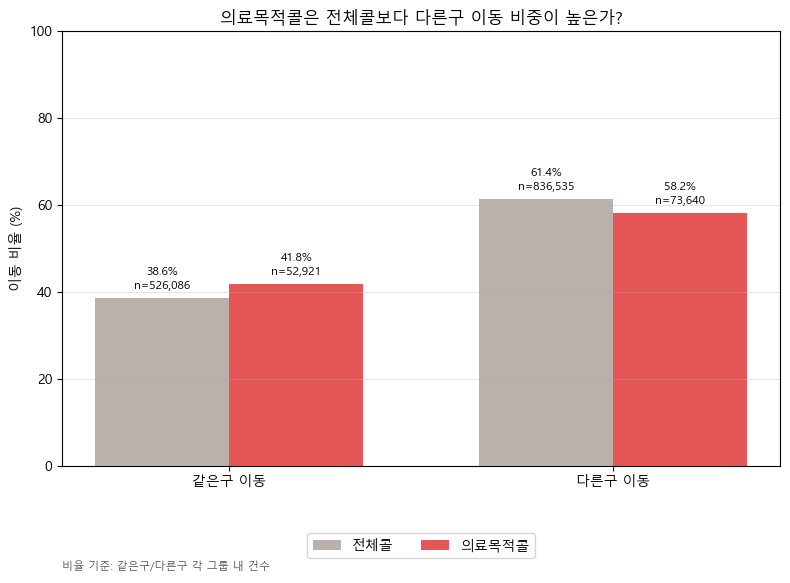

In [9]:
categories = comparison_df["구분"].tolist()
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

bars_all = ax.bar(x - width / 2, comparison_df["전체콜_비율"], width, label="전체콜", color="#bab0ac")
bars_med = ax.bar(x + width / 2, comparison_df["의료목적콜_비율"], width, label="의료목적콜", color="#e45756")

for bar, pct, n in zip(bars_all, comparison_df["전체콜_비율"], comparison_df["전체콜_건수"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{pct:.1f}%\nn={n:,}",
            ha="center", va="bottom", fontsize=8.5)
for bar, pct, n in zip(bars_med, comparison_df["의료목적콜_비율"], comparison_df["의료목적콜_건수"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{pct:.1f}%\nn={n:,}",
            ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 100)
ax.set_ylabel("이동 비율 (%)")
ax.set_title("의료목적콜은 전체콜보다 다른구 이동 비중이 높은가?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
ax.grid(axis="y", alpha=0.3)

ax.text(0.0, -0.24, "비율 기준: 같은구/다른구 각 그룹 내 건수", transform=ax.transAxes, fontsize=8, color="#555555")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_04_3_same_vs_diff_ratio_medical_vs_all.png", dpi=120, bbox_inches="tight")
plt.show()


읽는 법: 같은구/다른구 각각에서 전체콜과 의료목적콜의 이동 비중을 비교한다.


## 가설 1 해석

**[관찰]** 의료목적콜의 다른구 이동 비중은 58.2%(n=73,640)로, 전체콜의 다른구 비중 61.4%(n=836,535)보다 오히려 **낮았다**. 반대로 같은구 이동 비중은 의료목적콜 41.8%(n=52,921) vs 전체콜 38.6%(n=526,086)로 의료목적콜이 더 높았다.

**[해석]** 가설 1("의료목적콜은 다른구 이동 비중이 더 높을 것")은 **기각**됐다 — 방향이 예상과 반대다. 종합병원처럼 규모가 큰 시설을 찾아 구 경계를 넘는 사례가 있는 것은 사실이지만, 의료목적콜 전체를 보면 의원·한의원 등 동네에서 해결되는 방문 비중이 더 크게 작용해 오히려 같은구 비중이 높아진 것으로 추정된다.

**[추가 검증 필요]** 의료기관 종별·병상·의사 수와의 관계는 07 시리즈 결과와 함께 추가 확인한다. 특히 종합병원급 이상만 따로 떼어내 같은 비교를 반복하면 방향이 달라질 가능성이 있다.


In [10]:
medical_same_gu["5km이내"] = medical_same_gu["승차거리"] <= 5000
medical_diff_gu["5km이내"] = medical_diff_gu["승차거리"] <= 5000
medical_all = pd.concat([medical_same_gu, medical_diff_gu], ignore_index=True)


def coverage_stats(g):
    n = len(g)
    within = g["5km이내"].mean()
    return pd.Series({
        "건수": n,
        "5km이내비율(%)": within * 100,
        "5km초과비율(%)": (1 - within) * 100,
    })


medical_coverage_summary = pd.DataFrame({
    "같은구": coverage_stats(medical_same_gu),
    "다른구": coverage_stats(medical_diff_gu),
    "전체": coverage_stats(medical_all),
}).T
medical_coverage_summary.index.name = "구분"
display(medical_coverage_summary)

# 04_2에서 확정된 전체콜 5km 이내 비율(참고 텍스트 표시용)
ALL_CALL_COVERAGE = {"같은구": 88.748988, "다른구": 25.228831, "전체": 49.752939}


,건수,5km이내비율(%),5km초과비율(%)
구분,,,
같은구,52921.0,91.404168,8.595832
다른구,73640.0,30.448126,69.551874
전체,126561.0,55.936663,44.063337


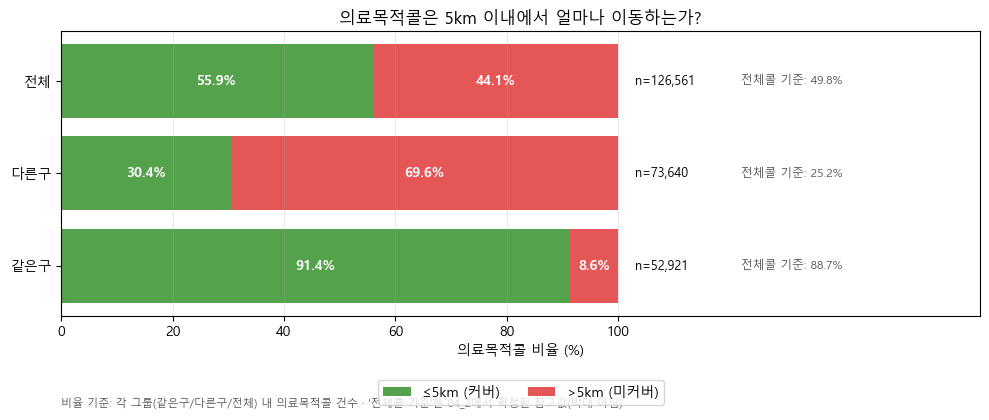

In [11]:
categories = ["같은구", "다른구", "전체"]
within_pct = medical_coverage_summary.loc[categories, "5km이내비율(%)"].tolist()
over_pct = medical_coverage_summary.loc[categories, "5km초과비율(%)"].tolist()
counts = medical_coverage_summary.loc[categories, "건수"].tolist()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(categories, within_pct, color="#54a24b", label="≤5km (커버)")
ax.barh(categories, over_pct, left=within_pct, color="#e45756", label=">5km (미커버)")

for i, (w, o, n, cat) in enumerate(zip(within_pct, over_pct, counts, categories)):
    ax.text(w / 2, i, f"{w:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(w + o / 2, i, f"{o:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(103, i, f"n={n:,.0f}", va="center", fontsize=9)
    ax.text(122, i, f"전체콜 기준: {ALL_CALL_COVERAGE[cat]:.1f}%", va="center", fontsize=8.5, color="#555555")

ax.set_xlim(0, 165)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlabel("의료목적콜 비율 (%)")
ax.set_title("의료목적콜은 5km 이내에서 얼마나 이동하는가?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.grid(axis="x", alpha=0.3)

ax.text(
    0.0, -0.32,
    "비율 기준: 각 그룹(같은구/다른구/전체) 내 의료목적콜 건수 · '전체콜 기준'은 04_2에서 확정된 참고값(막대 아님)",
    transform=ax.transAxes, fontsize=8, color="#555555",
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_04_3_5km_coverage_medical.png", dpi=120, bbox_inches="tight")
plt.show()


읽는 법: 각 그룹을 100%로 봤을 때 5km 이내에서 이동한 비중을 비교한다. 옆의 "전체콜 기준"은 막대가 아니라 04_2에서 이미 확정된 참고 수치다.


## 가설 2 1차 해석 (5km 커버리지 기준)

**[관찰]** 의료목적콜의 5km 이내 비율은 전체 기준 55.9%로, 전체콜의 49.8%보다 오히려 **높았다**. 같은구(91.4% vs 88.7%)·다른구(30.4% vs 25.2%) 모두 의료목적콜 쪽이 5km 이내 비율이 더 높다.

**[해석]** 가설 2("의료목적콜의 5km 이내 비율은 더 낮을 것")도 **기각**됐다 — 가설 1과 같은 방향의 반전이다. 의료목적콜이 일반 용무보다 오히려 더 가까운 거리에서 해결되는 경향이 있다는 뜻이며, 이는 거동이 불편한 이용자가 원거리 이동을 피하려 하거나, 동네 의원·한의원 방문 비중이 커서 나타나는 패턴일 수 있다.


In [12]:
bins_m = [0, 1000, 2000, 3000, 4000, 5000, 10000, 20000, float("inf")]
band_labels = ["0~1km", "1~2km", "2~3km", "3~4km", "4~5km", "5~10km", "10~20km", "20km+"]

medical_same_gu["거리구간"] = pd.cut(medical_same_gu["승차거리"], bins=bins_m, labels=band_labels, right=True, include_lowest=True)
medical_diff_gu["거리구간"] = pd.cut(medical_diff_gu["승차거리"], bins=bins_m, labels=band_labels, right=True, include_lowest=True)

band_same_medical = (medical_same_gu["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100)
band_diff_medical = (medical_diff_gu["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100)

display(pd.DataFrame({"같은구(%)": band_same_medical, "다른구(%)": band_diff_medical}))


,같은구(%),다른구(%)
거리구간,,
0~1km,7.354358,0.305540
1~2km,24.906937,2.274579
2~3km,26.089832,6.438077
3~4km,20.511706,9.621130
4~5km,12.541335,11.808800
5~10km,8.429546,35.939707
10~20km,0.158727,23.955731
20km+,0.007558,9.656437


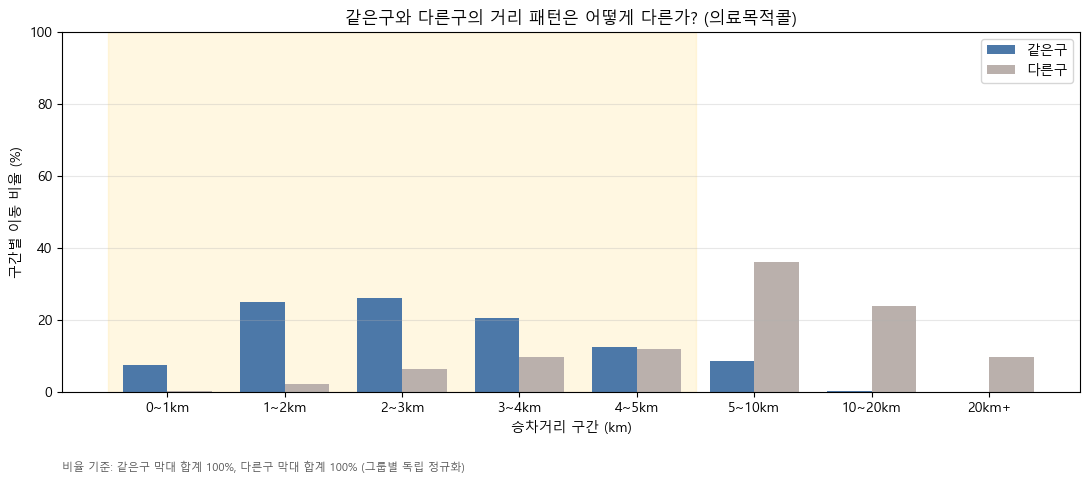

In [13]:
x = np.arange(len(band_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, band_same_medical.values, width, label="같은구", color="#4c78a8")
ax.bar(x + width / 2, band_diff_medical.values, width, label="다른구", color="#bab0ac")

ax.axvspan(-0.5, 4.5, color="#ffe08a", alpha=0.25, zorder=0)  # 0~5km 구간 강조

ax.set_xticks(x)
ax.set_xticklabels(band_labels)
ax.set_ylim(0, 100)
ax.set_xlabel("승차거리 구간 (km)")
ax.set_ylabel("구간별 이동 비율 (%)")
ax.set_title("같은구와 다른구의 거리 패턴은 어떻게 다른가? (의료목적콜)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax.text(
    0.0, -0.22,
    "비율 기준: 같은구 막대 합계 100%, 다른구 막대 합계 100% (그룹별 독립 정규화)",
    transform=ax.transAxes, fontsize=8, color="#555555",
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_04_3_distance_band_medical_same_vs_diff.png", dpi=120, bbox_inches="tight")
plt.show()


읽는 법: 같은구와 다른구 각각의 이동거리가 어느 구간에 집중되는지 비교한다.


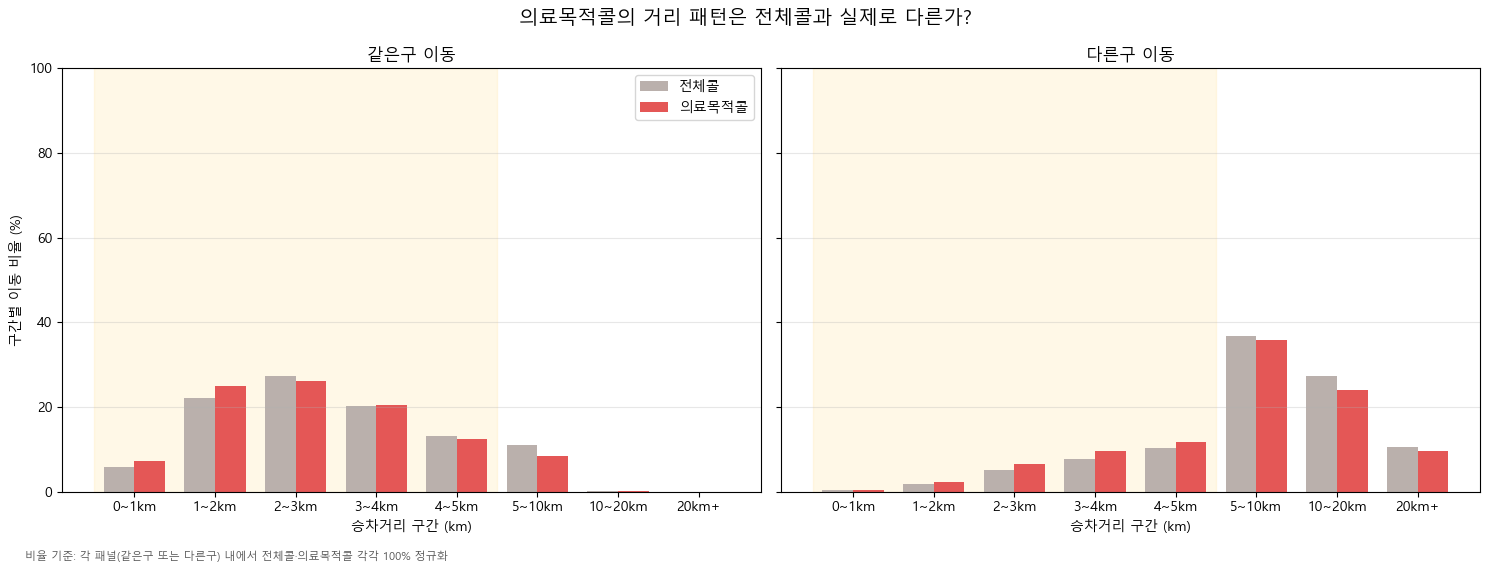

In [14]:
# 04_2에서 확정된 전체콜 거리구간별 구성비(참고값)
ALL_CALL_BAND_SAME = pd.Series(
    [5.772630, 22.210817, 27.254859, 20.354277, 13.156404, 10.982045, 0.253000, 0.015967],
    index=band_labels,
)
ALL_CALL_BAND_DIFF = pd.Series(
    [0.357307, 1.869497, 5.093989, 7.622873, 10.285164, 36.867435, 27.420969, 10.482765],
    index=band_labels,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

panels = [
    ("같은구 이동", ALL_CALL_BAND_SAME, band_same_medical, axes[0]),
    ("다른구 이동", ALL_CALL_BAND_DIFF, band_diff_medical, axes[1]),
]

for title, all_band, med_band, ax in panels:
    xi = np.arange(len(band_labels))
    w = 0.38
    ax.bar(xi - w / 2, all_band.values, w, label="전체콜", color="#bab0ac")
    ax.bar(xi + w / 2, med_band.values, w, label="의료목적콜", color="#e45756")
    ax.axvspan(-0.5, 4.5, color="#ffe08a", alpha=0.2, zorder=0)
    ax.set_xticks(xi)
    ax.set_xticklabels(band_labels)
    ax.set_ylim(0, 100)  # 두 패널 모두 강제 고정(자동 스케일 금지)
    ax.set_xlabel("승차거리 구간 (km)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("구간별 이동 비율 (%)")
axes[0].legend(loc="upper right")
fig.suptitle("의료목적콜의 거리 패턴은 전체콜과 실제로 다른가?", fontsize=14)

fig.text(0.02, -0.02, "비율 기준: 각 패널(같은구 또는 다른구) 내에서 전체콜·의료목적콜 각각 100% 정규화", fontsize=8, color="#555555")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_04_3_distance_band_medical_vs_all.png", dpi=120, bbox_inches="tight")
plt.show()


읽는 법: 의료목적콜의 거리분포가 전체콜과 실제로 다른지, 같은구·다른구 각각에서 확인한다. 두 패널 모두 Y축이 0~100%로 동일하게 고정돼 있으므로 막대 높이를 그대로 비교할 수 있다.


## `가설 2 최종 해석 (5km 커버리지 + 거리분포 종합)

**[관찰]** 거리구간별로 봐도 같은 방향이 확인된다. 같은구 이동에서 의료목적콜은 0~2km 구간(7.4%+24.9%=32.3%)이 전체콜(5.8%+22.2%=28.0%)보다 비중이 높고, 5~10km 구간은 의료목적콜 8.4% vs 전체콜 11.0%로 더 낮다. 다른구 이동에서도 의료목적콜은 2~5km 구간(6.4%+9.6%+11.8%=27.9%)이 전체콜(5.1%+7.6%+10.3%=23.0%)보다 비중이 높고, 10~20km 구간은 의료목적콜 24.0% vs 전체콜 27.4%로 더 낮다.

**[해석]** 가설 1·2 모두 예상과 반대 방향으로 기각됐다 — 의료목적콜은 전체콜보다 **① 같은구 안에서 더 많이 해결되고, ② 같은구·다른구 어느 쪽이든 더 가까운 거리에 몰려 있다.** "의료기관은 특정 구에 편중돼 있어 환자가 더 멀리 이동할 것"이라는 가설의 전제 자체는 07 시리즈에서 사실로 확인됐지만(마포구·서대문구·양천구 인프라 少), 실제 이동 데이터에는 그 효과보다 "동네에서 해결 가능한 의료 수요(의원·한의원 등)가 다수를 차지하는 효과"가 더 크게 나타난 것으로 보인다.`

**서비스 설계 시사점**: Part 3에서 검토했던 "의료 목적지는 5km 컷오프를 완화해야 한다"는 방향은 **이번 데이터로는 뒷받침되지 않는다** — 오히려 의료목적콜에는 일반콜보다 5km 이내 우선 안내를 적용해도 커버리지가 더 높다(55.9% vs 49.8%). 다만 이 결과는 "의료목적콜 전체"의 평균이므로, 종합병원급 이상만 따로 보면 결론이 달라질 수 있다는 점은 유의해야 한다(아래 추가 검증 필요 참고).

**[추가 검증 필요]** 시간대별·차량구분별(특장차/임차택시) 차이, 그리고 의료기관 종별(의원·한의원 vs 종합병원 이상)별로 나눈 재분석은 이번 범위 밖이며 후속 과제로 남긴다.


In [15]:
result_to_save = medical_coverage_summary.reset_index()
save_path = DATA_DIR / "region_medical_purpose_5km_coverage_same_vs_diff_gu_20251231.csv"
result_to_save.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path}")
display(result_to_save)

assert len(medical_same_gu) + len(medical_diff_gu) == len(medical_completed), "같은구+다른구 합이 의료목적 모집단과 불일치"
print("\n검증 통과 — 같은구+다른구 = 의료목적콜 서울 25구 전체")


저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_medical_purpose_5km_coverage_same_vs_diff_gu_20251231.csv


,구분,건수,5km이내비율(%),5km초과비율(%)
0,같은구,52921.0,91.404168,8.595832
1,다른구,73640.0,30.448126,69.551874
2,전체,126561.0,55.936663,44.063337



검증 통과 — 같은구+다른구 = 의료목적콜 서울 25구 전체


## 종합 인사이트

**[관찰]** 가설 1(다른구 이동 비중)·가설 2(5km 이내 비율) 모두 예상과 **반대 방향**으로 기각됐다 — 의료목적콜은 전체콜보다 같은구 이동 비중이 높고(41.8% vs 38.6%), 5km 이내 비율도 더 높다(55.9% vs 49.8%, 같은구 91.4% vs 88.7%, 다른구 30.4% vs 25.2%).

**[해석]** "의료기관의 지역적 편중 때문에 의료목적콜이 더 멀리 이동할 것"이라는 전제(07 시리즈에서 확인된 사실)는 맞지만, 실제 의료목적콜 데이터 전체에는 동네에서 해결되는 근거리 의료 수요(의원·한의원 등)의 비중이 더 크게 반영돼 반대 방향의 결과가 나타난 것으로 해석된다. `07_2_medical_destination_analysis_and_insights.ipynb`의 순유입·순유출 지도와 함께 보면, 종합병원이 몰려 있는 구(예: 서대문구·영등포구·강동구가 순유입 상위)는 실제로 원거리에서 환자를 끌어오는 반면, 그 효과가 전체 평균을 뒤집을 만큼 크지는 않다는 뜻이다.

**서비스 설계 시사점**: "의료 목적지는 5km 컷오프를 완화해야 한다"는 가설은 이번 분석으로는 기각됐다 — 의료목적콜 전체 기준으로는 오히려 5km 이내 우선 안내의 커버리지가 일반콜보다 높다. 다만 이는 의원·한의원을 포함한 "의료목적콜 전체"의 평균이므로, 종합병원급 이상 목적지만 따로 떼어내 재검증하기 전까지는 "모든 의료 목적지에 적용 가능하다"고 일반화하지 않는다.

**[추가 검증 필요]**
- 종합병원·상급종합병원만 따로 분리한 재분석(의원·한의원 제외) — 07 시리즈가 지적한 "인프라 편중" 효과가 이 하위집합에서는 더 뚜렷하게 나타날 가능성이 있다.
- 시간대별·차량구분별(특장차/임차택시) 차이는 이번 범위 밖.
- `07_2`의 순유입·순유출과 자치구 단위로 교차 결합하면 "어느 구가 의료목적콜을 실제로 끌어오는지" 더 구체적으로 볼 수 있다.

**한계**:
- 100km 초과 이상치만 제거했고, 그 외 극단치는 그대로 포함돼 있다.
- 의료목적 필터(`이용목적` 컬럼 기준)는 실제 방문 목적을 완벽히 반영하지 못할 수 있다(예: '기타'로 기록된 병원 방문 등은 포함되지 않음).
